<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
         width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# The Heston Model — European Call Pricing
---
Implementacion paso a paso del pricing de un call europeo bajo Heston:

$$\text{SDEs de Heston} \;\xrightarrow{\text{Feynman-Kac + forma propuesta}}\;
\varphi_j(u) \;\xrightarrow{\text{Inversion de Fourier}}\;
P_1, P_2 \;\longrightarrow\; C = S_t P_1 - Ke^{-r\\tau}P_2$$

**Referencia:** Heston (1993); forma estable: Albrecher et al. (2007) *The Little Heston Trap.*


## Librerias

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'lines.linewidth'  : 2,
})

PURPLE = '#534AB7'
GREEN  = '#1D9E75'
ORANGE = '#D85A30'
AMBER  = '#BA7517'
BLUE   = '#2A7FBF'


## 1. Parametros

| Parametro | Simbolo | Valor | Significado |
|-----------|---------|-------|-------------|
| Precio spot | $S_0$ | 100 | Precio actual del activo |
| Strike | $K$ | 100 | Precio de ejercicio (ATM) |
| Tasa libre de riesgo | $r$ | 5% | Continua, anualizada |
| Madurez | $\tau$ | 1 año | Tiempo al vencimiento |
| Varianza inicial | $v_0$ | 0.04 | Vol inicial = 20% |
| Velocidad de reversion | $\kappa$ | 2.0 | Rapidez con que $v_t$ regresa a $\theta$ |
| Varianza de largo plazo | $\theta$ | 0.04 | Vol largo plazo |
| Vol de la vol | $\xi$ | 0.30 | Cuanto fluctua la varianza |
| Correlacion | $\rho$ | -0.70 | Efecto leverage (skew negativo) |


In [2]:
# Parametros de mercado
S0  = 100.0
K   = 100.0
r   = 0.05
tau = 1.0

# Parametros de Heston
v0    = 0.04
kappa = 2.0
theta = 0.04
xi    = 0.30
rho   = -0.70

sigma_bs = np.sqrt(theta)   # volatilidad B&S de referencia (20%)

print(f"Volatilidad B&S de referencia : {sigma_bs:.1%}")
feller = 2*kappa*theta > xi**2
print(f"Condicion de Feller 2*kappa*theta > xi^2 : {2*kappa*theta:.3f} > {xi**2:.3f}",
      "OK" if feller else "VIOLADA (v puede tocar cero)")


Volatilidad B&S de referencia : 20.0%
Condicion de Feller 2*kappa*theta > xi^2 : 0.160 > 0.090 OK


## 2. Black-Scholes (referencia)

$$C_{BS} = S_0\,\mathcal{N}(d_1) - Ke^{-r\\tau}\,\mathcal{N}(d_2)$$


In [3]:
def bs_call(S, K, r, tau, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S*norm.cdf(d1) - K*np.exp(-r*tau)*norm.cdf(d2), norm.cdf(d1), norm.cdf(d2)

def bs_implied_vol(price, S, K, r, tau, tol=1e-7):
    intrinsic = max(S - K*np.exp(-r*tau), 0.0)
    if price <= intrinsic + 1e-8:
        return np.nan
    lo, hi = 1e-6, 5.0
    for _ in range(200):
        mid = (lo + hi) / 2.0
        diff = bs_call(S, K, r, tau, mid)[0] - price
        if abs(diff) < tol:
            return mid
        lo, hi = (mid, hi) if diff < 0 else (lo, mid)
    return mid


## 3. Funcion Caracteristica de Heston (forma estable)

$$\varphi_j(u) = e^{C_j + D_j v + iux}$$

Cantidades auxiliares (slide *Auxiliary Quantities*):

$$d_j = \\sqrt{(\\rho\\xi\,iu - b_j)^2 + \\xi^2(u^2 - 2u_j\,iu)}
\\qquad
g_{2j} = \\frac{b_j - \\rho\\xi\,iu + d_j}{b_j - \\rho\\xi\,iu - d_j}$$

| | $u_j$ | $b_j$ |
|--|--|--|
| $j=1$ ($P_1$, medida accion) | $+1/2$ | $\\kappa - \\rho\\xi$ |
| $j=2$ ($P_2$, medida riesgo-neutral) | $-1/2$ | $\\kappa$ |


In [4]:
def heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho):
    """
    Funcion caracteristica de Heston phi_j(u) -- forma estable (Little Trap).
    j=1 -> medida accion (P1),  j=2 -> medida riesgo-neutral (P2).
    """
    i  = 1j
    uj = 0.5             if j == 1 else -0.5
    bj = kappa - rho*xi  if j == 1 else  kappa

    # Cantidades auxiliares
    dj  = np.sqrt((rho*xi*i*u - bj)**2 + xi**2*(u**2 - 2*uj*i*u))
    g2j = (bj - rho*xi*i*u + dj) / (bj - rho*xi*i*u - dj)

    # Solucion de las ODEs (slide: Solving for D / Solving for C)
    Dj = ((bj - rho*xi*i*u + dj) / xi**2) *          ((1 - np.exp(dj*tau)) / (1 - g2j*np.exp(dj*tau)))

    Cj = r*i*u*tau + (kappa*theta/xi**2) * (
            (bj - rho*xi*i*u + dj)*tau
            - 2*np.log((1 - g2j*np.exp(dj*tau)) / (1 - g2j)))

    # Forma propuesta: phi = exp[C + D*v + i*u*x]
    return np.exp(Cj + Dj*v + i*u*x)


## 4. Inversion de Fourier -> $P_1$ y $P_2$

$$P_j = \frac{1}{2} + \frac{1}{\pi}
\int_0^{\infty} \operatorname{Re}\!\left[
\frac{e^{-iu\ln K}\,\varphi_j(u)}{iu}
\right]du$$


In [5]:
def heston_prob_j(j, x, v, tau, K, r, kappa, theta, xi, rho):
    """Probabilidad P_j via inversion de Fourier (Gil-Pelaez, 1951)."""
    lnK = np.log(K)
    def integrand(u):
        phi = heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho)
        return np.real(np.exp(-1j*u*lnK) * phi / (1j*u))
    val, _ = quad(integrand, 1e-8, 500, limit=300)
    return 0.5 + val / np.pi

def heston_call(S, K, r, tau, v0, kappa, theta, xi, rho):
    """Precio de call europeo bajo Heston: C = S*P1 - K*exp(-r*tau)*P2"""
    x  = np.log(S)
    P1 = heston_prob_j(1, x, v0, tau, K, r, kappa, theta, xi, rho)
    P2 = heston_prob_j(2, x, v0, tau, K, r, kappa, theta, xi, rho)
    return S*P1 - K*np.exp(-r*tau)*P2, P1, P2


## 5. Comparacion puntual: B&S vs Heston (call ATM)

In [6]:
bs_price, Nd1, Nd2 = bs_call(S0, K, r, tau, sigma_bs)
h_price,  P1,  P2  = heston_call(S0, K, r, tau, v0, kappa, theta, xi, rho)

print("=" * 52)
print(f"  {'':20s}  {'Black-Scholes':>12}  {'Heston':>10}")
print("=" * 52)
print(f"  {'Precio del call':20s}  {bs_price:>12.4f}  {h_price:>10.4f}")
print(f"  {'P1  /  N(d1)':20s}  {Nd1:>12.4f}  {P1:>10.4f}")
print(f"  {'P2  /  N(d2)':20s}  {Nd2:>12.4f}  {P2:>10.4f}")
print("=" * 52)
print(f"  Diferencia Heston - B&S  :  {h_price - bs_price:+.4f}")


                        Black-Scholes      Heston
  Precio del call            10.4506     10.3942
  P1  /  N(d1)                0.6368      0.6919
  P2  /  N(d2)                0.5596      0.6181
  Diferencia Heston - B&S  :  -0.0564


## 6. Visualizacion 1 - Precio del call vs Strike

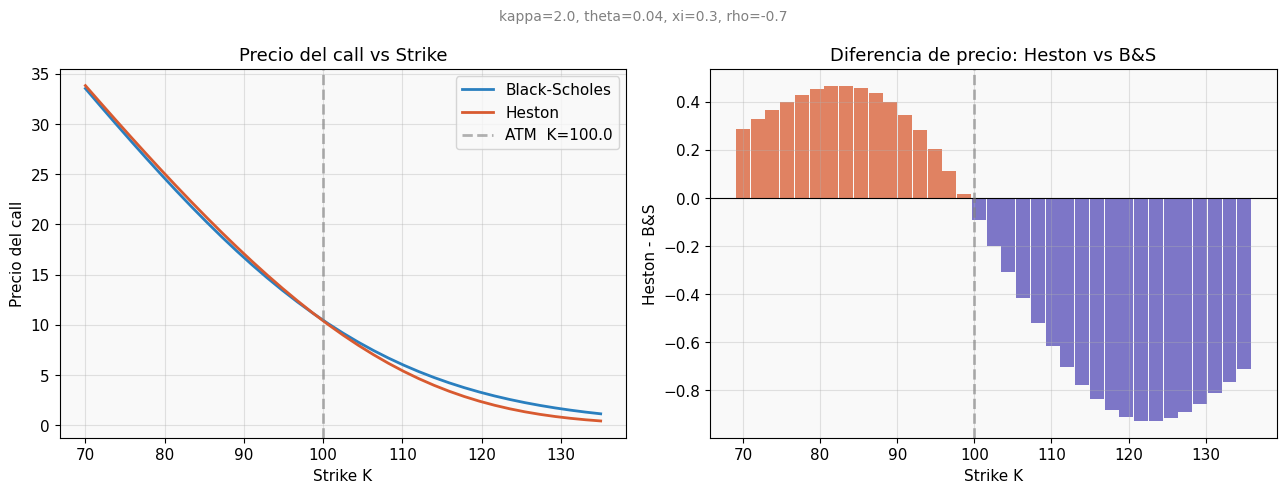

In [7]:
strikes = np.linspace(70, 135, 35)

prices_bs = np.array([bs_call(S0, k, r, tau, sigma_bs)[0] for k in strikes])
prices_h  = []
for k in strikes:
    p, _, _ = heston_call(S0, k, r, tau, v0, kappa, theta, xi, rho)
    prices_h.append(p)
prices_h = np.array(prices_h)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(strikes, prices_bs, color=BLUE,   lw=2, label='Black-Scholes')
ax.plot(strikes, prices_h,  color=ORANGE, lw=2, label='Heston')
ax.axvline(K, color='gray', ls='--', alpha=0.6, label=f'ATM  K={K}')
ax.set_xlabel('Strike K');  ax.set_ylabel('Precio del call')
ax.set_title('Precio del call vs Strike');  ax.legend()

ax = axes[1]
diff = prices_h - prices_bs
ax.bar(strikes, diff, width=1.8,
       color=[ORANGE if d > 0 else PURPLE for d in diff], alpha=0.75)
ax.axhline(0, color='black', lw=0.8);  ax.axvline(K, color='gray', ls='--', alpha=0.6)
ax.set_xlabel('Strike K');  ax.set_ylabel('Heston - B&S')
ax.set_title('Diferencia de precio: Heston vs B&S')

plt.suptitle(f'kappa={kappa}, theta={theta}, xi={xi}, rho={rho}', fontsize=10, color='gray')
plt.tight_layout();  plt.show()


## 7. Visualizacion 2 - Sonrisa de volatilidad implicita

**Este es el grafico clave.** B&S produce una IV plana. Heston produce el skew que
se observa en el mercado real.


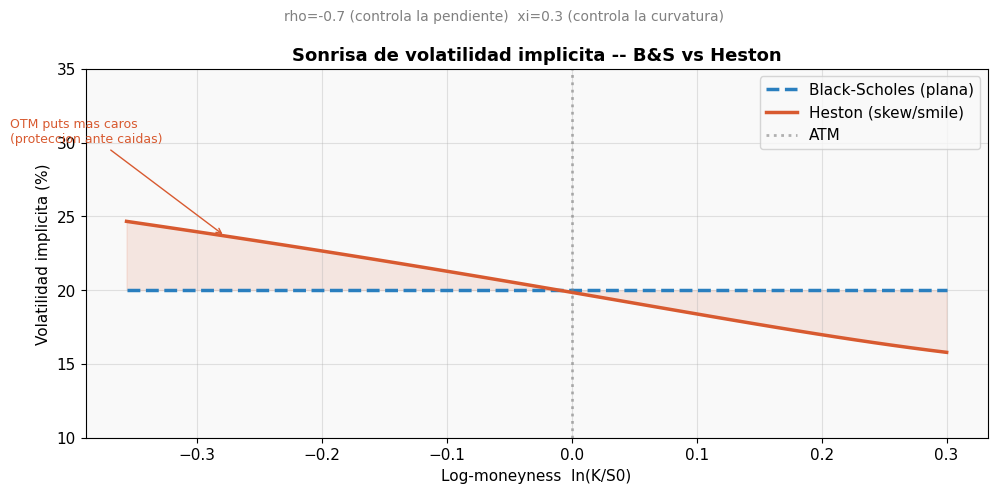

In [8]:
logm      = np.log(strikes / S0)
ivols_bs  = np.full(len(strikes), sigma_bs)
ivols_h   = np.array([bs_implied_vol(p, S0, k, r, tau)
                       for p, k in zip(prices_h, strikes)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(logm, ivols_bs*100, color=BLUE,   lw=2.5, ls='--', label='Black-Scholes (plana)')
ax.plot(logm, ivols_h*100,  color=ORANGE, lw=2.5,           label='Heston (skew/smile)')
ax.fill_between(logm, ivols_bs*100, ivols_h*100, alpha=0.12, color=ORANGE)
ax.axvline(0, color='gray', ls=':', alpha=0.6, label='ATM')
ax.set_xlabel('Log-moneyness  ln(K/S0)')
ax.set_ylabel('Volatilidad implicita (%)')
ax.set_title('Sonrisa de volatilidad implicita -- B&S vs Heston', fontweight='bold')
ax.legend();  ax.set_ylim(10, 35)
ax.annotate('OTM puts mas caros\n(proteccion ante caidas)',
            xy=(logm[3], ivols_h[3]*100), xytext=(-0.45, 30),
            arrowprops=dict(arrowstyle='->', color=ORANGE), color=ORANGE, fontsize=9)
plt.suptitle(f'rho={rho} (controla la pendiente)  xi={xi} (controla la curvatura)',
             fontsize=10, color='gray')
plt.tight_layout();  plt.show()


## 8. Visualizacion 3 - La funcion caracteristica phi_2(u)

Parte real e imaginaria de phi_2(u): muestra por que necesitamos inversion
numerica en lugar de una antitransformada analitica.


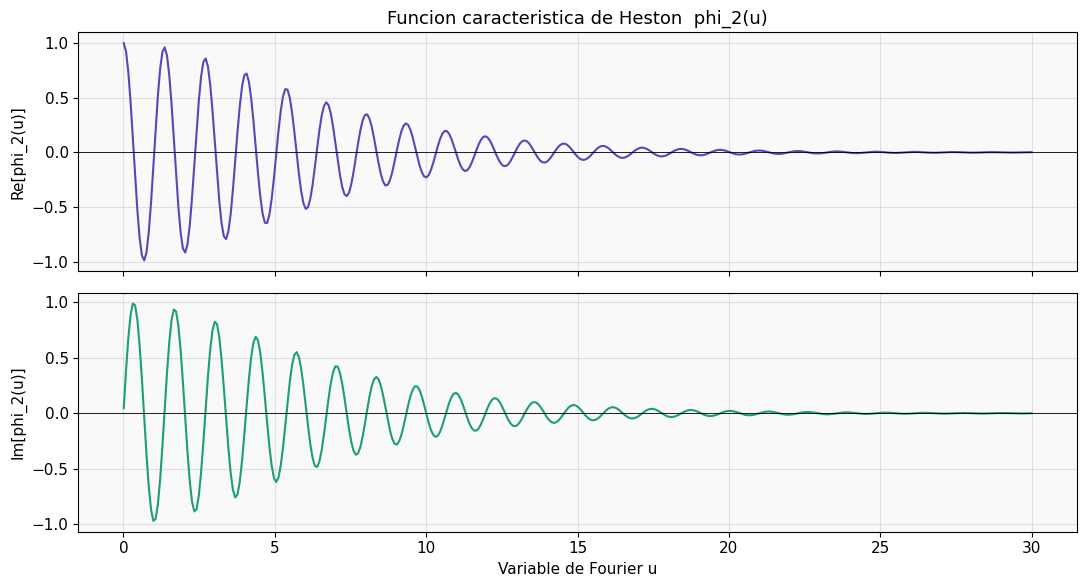

In [9]:
us       = np.linspace(0.01, 30, 400)
x_log   = np.log(S0)
phi_vals = np.array([heston_cf_j(u, 2, x_log, v0, tau, r, kappa, theta, xi, rho)
                     for u in us])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(us, phi_vals.real, color=PURPLE, lw=1.5)
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_ylabel('Re[phi_2(u)]')
axes[0].set_title('Funcion caracteristica de Heston  phi_2(u)')
axes[1].plot(us, phi_vals.imag, color=GREEN,  lw=1.5)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_ylabel('Im[phi_2(u)]');  axes[1].set_xlabel('Variable de Fourier u')
plt.tight_layout();  plt.show()


## 9. Visualizacion 4 - $P_1, P_2$ vs $\mathcal{N}(d_1), \mathcal{N}(d_2)$

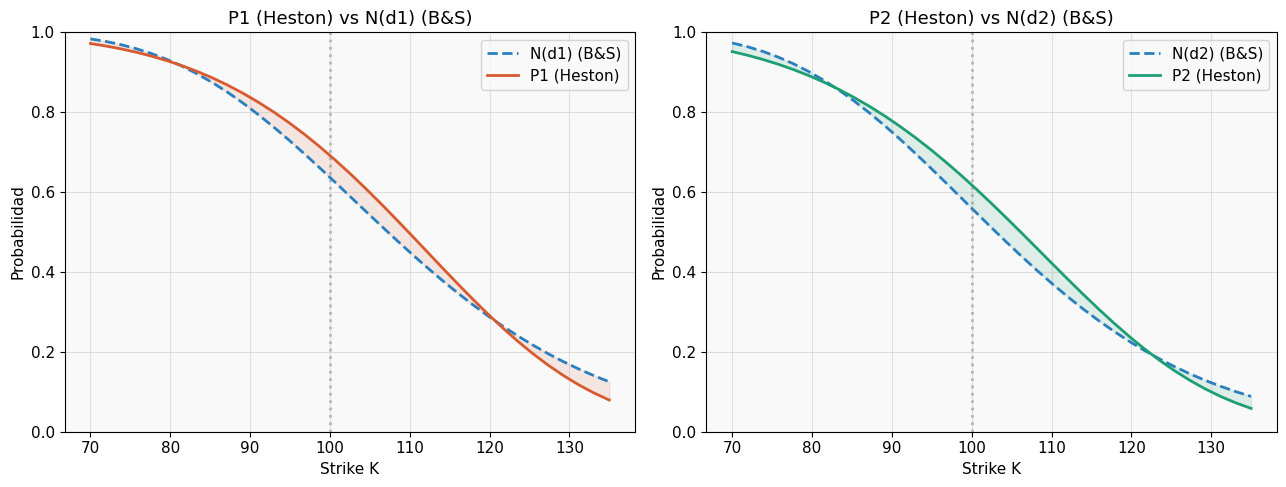

In [10]:
p1v=[]; p2v=[]; nd1v=[]; nd2v=[]
for k in strikes:
    _, p1, p2 = heston_call(S0, k, r, tau, v0, kappa, theta, xi, rho)
    _, nd1, nd2 = bs_call(S0, k, r, tau, sigma_bs)
    p1v.append(p1); p2v.append(p2); nd1v.append(nd1); nd2v.append(nd2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, hv, bv, lbl, col in [
        (axes[0], p1v, nd1v, ('P1 (Heston)', 'N(d1) (B&S)'), ORANGE),
        (axes[1], p2v, nd2v, ('P2 (Heston)', 'N(d2) (B&S)'), GREEN)]:
    ax.plot(strikes, bv, color=BLUE, lw=2, ls='--', label=lbl[1])
    ax.plot(strikes, hv, color=col,  lw=2,           label=lbl[0])
    ax.fill_between(strikes, bv, hv, alpha=0.12, color=col)
    ax.axvline(K, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('Strike K');  ax.set_ylabel('Probabilidad')
    ax.set_title(f'{lbl[0]} vs {lbl[1]}');  ax.legend();  ax.set_ylim(0, 1)
plt.tight_layout();  plt.show()


## 10. Visualizacion 5 - Efecto de $\rho$ en el skew

$\rho$ controla la **pendiente** de la sonrisa.


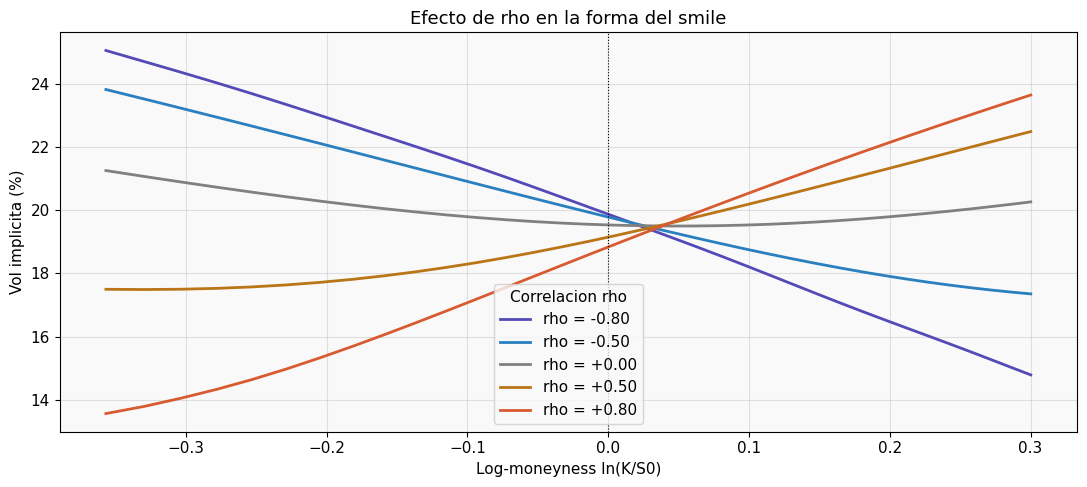

In [11]:
rhos   = [-0.80, -0.50, 0.0, 0.50, 0.80]
colors = [PURPLE, BLUE, 'gray', AMBER, ORANGE]

fig, ax = plt.subplots(figsize=(11, 5))
for rho_i, col in zip(rhos, colors):
    ivs = []
    for k in strikes:
        p, _, _ = heston_call(S0, k, r, tau, v0, kappa, theta, xi, rho_i)
        ivs.append(bs_implied_vol(p, S0, k, r, tau))
    ax.plot(logm, np.array(ivs)*100, color=col, lw=2, label=f'rho = {rho_i:+.2f}')
ax.axvline(0, color='black', ls=':', lw=0.8)
ax.set_xlabel('Log-moneyness ln(K/S0)');  ax.set_ylabel('Vol implicita (%)')
ax.set_title('Efecto de rho en la forma del smile');  ax.legend(title='Correlacion rho')
plt.tight_layout();  plt.show()


## 11. Visualizacion 6 - Efecto de $\xi$ en la curvatura

$\xi$ (vol de la vol) controla la **curvatura** de la sonrisa.


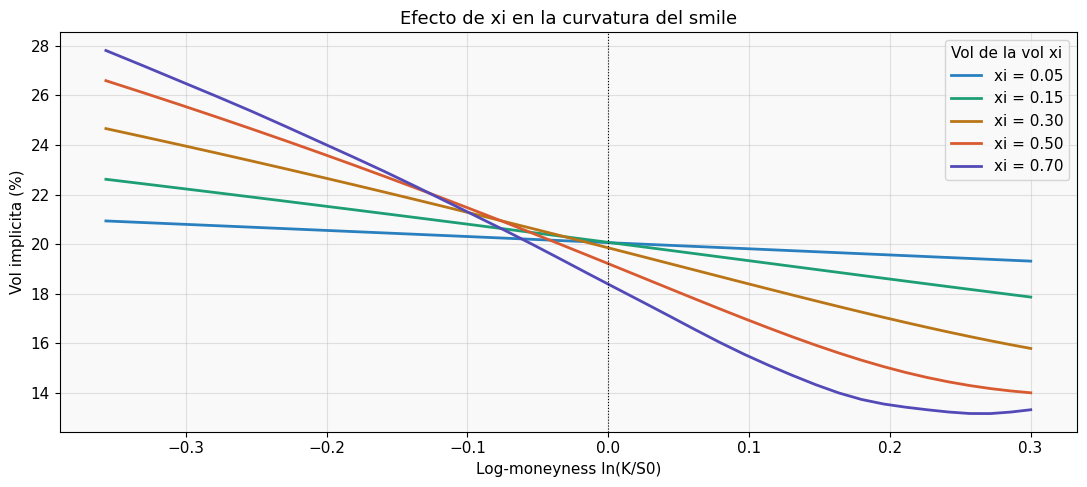

In [12]:
xis    = [0.05, 0.15, 0.30, 0.50, 0.70]
colors = [BLUE, GREEN, AMBER, ORANGE, PURPLE]

fig, ax = plt.subplots(figsize=(11, 5))
for xi_i, col in zip(xis, colors):
    ivs = []
    for k in strikes:
        p, _, _ = heston_call(S0, k, r, tau, v0, kappa, theta, xi_i, rho)
        ivs.append(bs_implied_vol(p, S0, k, r, tau))
    ax.plot(logm, np.array(ivs)*100, color=col, lw=2, label=f'xi = {xi_i:.2f}')
ax.axvline(0, color='black', ls=':', lw=0.8)
ax.set_xlabel('Log-moneyness ln(K/S0)');  ax.set_ylabel('Vol implicita (%)')
ax.set_title('Efecto de xi en la curvatura del smile');  ax.legend(title='Vol de la vol xi')
plt.tight_layout();  plt.show()


## 12. Visualizacion 7 - Superficie de volatilidad implicita

Volatilidad implicita como funcion de (Strike, Madurez).
Esta es la superficie que se usa para calibrar el modelo al mercado.


Calculando superficie... (~30 segundos)
  tau = 0.25a completado
  tau = 0.50a completado
  tau = 0.75a completado
  tau = 1.00a completado
  tau = 1.50a completado
  tau = 2.00a completado


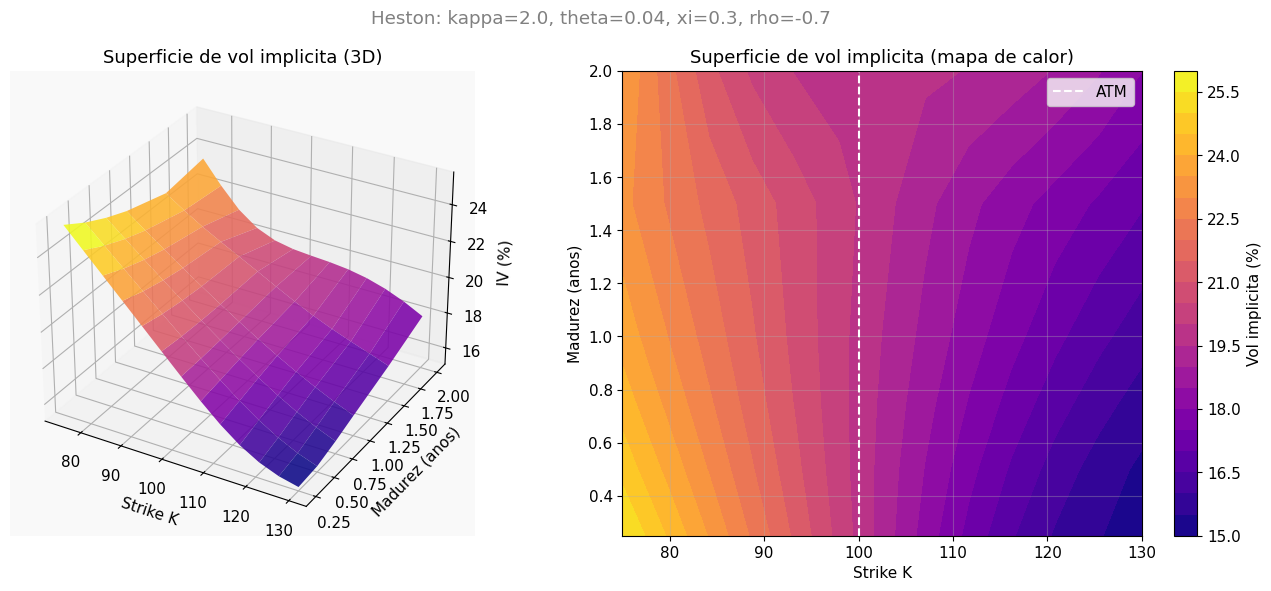

In [13]:
strikes_s = np.linspace(75, 130, 13)
taus_s    = np.array([0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

print("Calculando superficie... (~30 segundos)")
IV = np.full((len(taus_s), len(strikes_s)), np.nan)
for i, t in enumerate(taus_s):
    for j, k in enumerate(strikes_s):
        p, _, _ = heston_call(S0, k, r, t, v0, kappa, theta, xi, rho)
        IV[i, j] = bs_implied_vol(p, S0, k, r, t) * 100
    print(f"  tau = {t:.2f}a completado")

Kg, Tg = np.meshgrid(strikes_s, taus_s)

fig = plt.figure(figsize=(14, 6))

ax3 = fig.add_subplot(121, projection='3d')
ax3.plot_surface(Kg, Tg, IV, cmap='plasma', alpha=0.88, edgecolor='none')
ax3.set_xlabel('Strike K');  ax3.set_ylabel('Madurez (anos)');  ax3.set_zlabel('IV (%)')
ax3.set_title('Superficie de vol implicita (3D)')

ax2 = fig.add_subplot(122)
im = ax2.contourf(Kg, Tg, IV, levels=20, cmap='plasma')
fig.colorbar(im, ax=ax2, label='Vol implicita (%)')
ax2.axvline(S0, color='white', ls='--', lw=1.5, label='ATM')
ax2.set_xlabel('Strike K');  ax2.set_ylabel('Madurez (anos)')
ax2.set_title('Superficie de vol implicita (mapa de calor)');  ax2.legend()

plt.suptitle(f'Heston: kappa={kappa}, theta={theta}, xi={xi}, rho={rho}', color='gray')
plt.tight_layout();  plt.show()


## 13. Resumen del flujo completo

```
Heston SDEs  (S_t, v_t)
     |  Feynman-Kac + forma propuesta  phi = exp[C + D*v + i*u*x]
     v
Funcion caracteristica phi_j(u, tau)   [forma cerrada, estable]
     |  Inversion de Fourier numerica
     v
P1, P2   (probabilidades bajo dos medidas distintas)
     |  Sustitucion en la formula de Heston
     v
C = S * P1 - K * exp(-r*tau) * P2
```

**Lo que Heston gana sobre B&S:**
- Genera una sonrisa/skew de vol implicita observable en el mercado.
- `rho` controla la pendiente;  `xi` controla la curvatura.
- Con xi -> 0 y v0 = theta = sigma^2, el modelo converge a B&S.

**El costo:** cada precio requiere una integral numerica 1D, pero es suficientemente rapido para calibracion en tiempo real.
